<a href="https://colab.research.google.com/github/MarilynMaika/NLP_REPO/blob/main/POS_tagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part-of-Speech Tagging Using Approaches on the Brown Corpus

The objective of this task is to implement and compare different Part-of-Speech (POS) tagging approaches using the Brown Corpus. The different approaches include:

- A rule-based POS tagger using morphological and contextual rules

- A unigram tagger based on word-level frequency distributions

- A Hidden Markov Model (HMM) tagger using probabilistic sequence modeling

- A Conditional Random Field (CRF) tagger using feature-based discriminative sequence modeling

The goal is to analyze how performance improves as the models progress from simple rule-based approaches to more advanced statistical and machine learning-based sequence models.

## Import Required Libraries

In [ ]:
import nltk
from nltk.corpus import brown
from nltk.tag import hmm
from nltk.tag import DefaultTagger

In [ ]:
## Downlooading a custom data set (the brown corpus)

## Downloading the Dataset

The Brown Corpus from the NLTK library is used as the dataset. It is a large, manually annotated corpus containing text from multiple genres. The Universal POS tagset is applied to simplify the classification task.

In [ ]:
nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

## Load the Dataset

In [ ]:
# Load tagged sentences from Brown Corpus
sentences = brown.tagged_sents(tagset='universal')

print("Number of sentences:", len(sentences))
print(sentences[0])

Number of sentences: 57340
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


## Split Dataset
The data set is split into the training and test set so we can evalaute the performance of the the POS taggers.

In [ ]:
train_size = int(len(sentences) * 0.8)

train_data = sentences[:train_size]
test_data = sentences[train_size:]

print("Training sentences:", len(train_data))
print("Testing sentences:", len(test_data))

Training sentences: 45872
Testing sentences: 11468


## **Different POS tagging Approaches**

## 1. Rule Based Tagger

This method uses predefined patterns (e.g., suffix rules like "-ing", "-ed", "-ly") to assign POS tags.



In [ ]:
from nltk.tag import RegexpTagger

rule_tagger = RegexpTagger([
    (r'.*ing$', 'VERB'),
    (r'.*ed$', 'VERB'),
    (r'.*ly$', 'ADV'),
    (r'.*ness$', 'NOUN'),
    (r'.*ment$', 'NOUN'),
    (r'.*ous$', 'ADJ'),
    (r'.*able$', 'ADJ'),
    (r'.*$', 'NOUN')
])



### Evaluating the rule based tagger

In [ ]:
rule_accuracy = rule_tagger.accuracy(test_data)

print("Rule-Based Accuracy:", rule_accuracy)

Rule-Based Accuracy: 0.2518535247265156


## 2.  Unigram Tagger
 The Unigram Tagger assigns each word the most frequent tag observed in the training corpus.

In [ ]:
from nltk.tag import UnigramTagger

unigram_tagger = UnigramTagger(train_data)



#### Evaluating the Unigram Tagger

In [ ]:
unigram_accuracy = unigram_tagger.accuracy(test_data)

print("Unigram Accuracy:", unigram_accuracy)

Unigram Accuracy: 0.9104359225760964


### 3. HMM (Hidden Markov Models) POS Tagger

A generative probabilistic model that considers both transition probabilities between tags and emission probabilities between words and tags.

In [ ]:
trainer = hmm.HiddenMarkovModelTrainer()

hmm_tagger = trainer.train(train_data)

#### Evaluating the HMM

In [ ]:
hmm_accuracy = hmm_tagger.accuracy(test_data)

print("HMM Accuracy:", hmm_accuracy)

/usr/local/lib/python3.12/dist-packages/nltk/tag/hmm.py:335: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])
/usr/local/lib/python3.12/dist-packages/nltk/tag/hmm.py:333: RuntimeWarning: overflow encountered in cast
  X[i, j] = self._transitions[si].logprob(self._states[j])
/usr/local/lib/python3.12/dist-packages/nltk/tag/hmm.py:363: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])


HMM Accuracy: 0.6854075551099996


## 4.  Conditional Random Fields (CRFs)

This is a discriminative sequence model that uses contextual features such as neighboring words, prefixes, suffixes, and capitalization

#### Feature Extraction

In [ ]:
def word2features(sent, i):
    word = sent[i][0]

    features = {
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'isupper': word.isupper(),
        'istitle': word.istitle(),
        'isdigit': word.isdigit(),
    }

    if i > 0:
        prev_word = sent[i-1][0]
        features.update({
            '-1:word.lower()': prev_word.lower(),
        })
    else:
        features['BOS'] = True

    if i < len(sent)-1:
        next_word = sent[i+1][0]
        features.update({
            '+1:word.lower()': next_word.lower(),
        })
    else:
        features['EOS'] = True

    return features

### Convert Sentences

In [ ]:
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, label in sent]

X_train = [sent2features(s) for s in train_data]
y_train = [sent2labels(s) for s in train_data]

X_test = [sent2features(s) for s in test_data]
y_test = [sent2labels(s) for s in test_data]

### Train the CRF

In [ ]:
import sklearn_crfsuite

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100
)

crf.fit(X_train, y_train)

CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100)

### Evaluating the CRF

In [ ]:
from sklearn_crfsuite import metrics

y_pred = crf.predict(X_test)

crf_accuracy = metrics.flat_accuracy_score(y_test, y_pred)

print("CRF Accuracy:", crf_accuracy)

CRF Accuracy: 0.9723871635838851


## Comparing Performance of all the models

In [ ]:
import pandas as pd

# Create a dictionary of tagger names and their accuracies
tagger_accuracies = {
    'Tagger': ['Rule-Based Tagger', 'Unigram Tagger', 'HMM Tagger', 'CRF Tagger'],
    'Accuracy': [rule_accuracy, unigram_accuracy, hmm_accuracy, crf_accuracy]
}

# Create a DataFrame from the dictionary
accuracy_df = pd.DataFrame(tagger_accuracies)

# Display the DataFrame
print(accuracy_df.to_markdown(index=False))

| Tagger            |   Accuracy |
|:------------------|-----------:|
| Rule-Based Tagger |   0.251854 |
| Unigram Tagger    |   0.910436 |
| HMM Tagger        |   0.685408 |
| CRF Tagger        |   0.972387 |


/tmp/ipykernel_4223/1525331286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tagger', y='Accuracy', data=accuracy_df, palette='viridis')


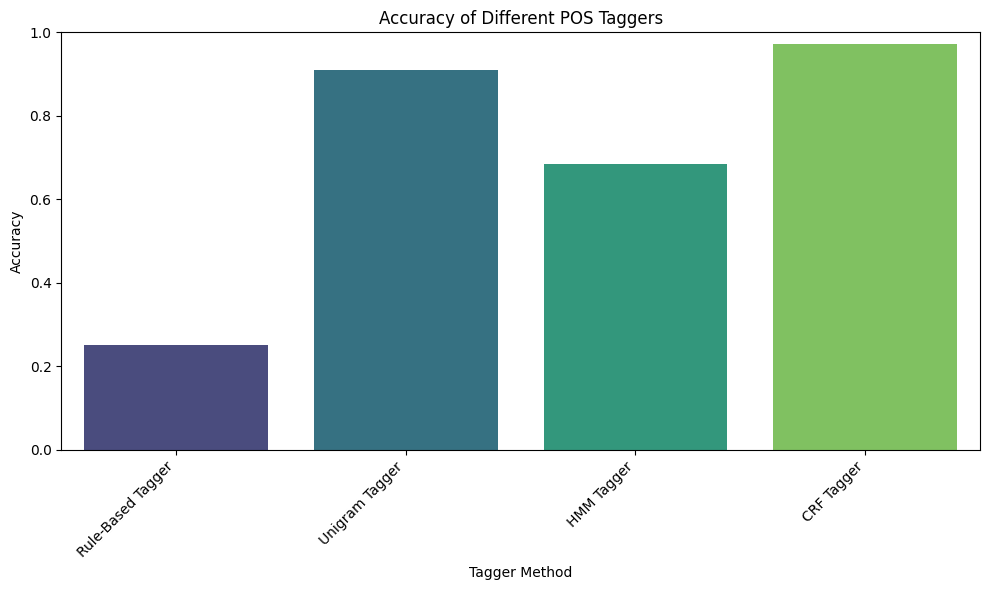

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Tagger', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Accuracy of Different POS Taggers')
plt.xlabel('Tagger Method')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the comparison above, we see that the CRF tagger appears to be the best performing POS tagger.

Using the CRF tagger

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab') # Add this line to download the missing resource

# Sample sentence
sample_sentence = "People who are crazy enough to think they can change the world are the ones who do"

# Tokenize
tokens2 = word_tokenize(sample_sentence.lower())

# Convert into CRF input format (dummy tags required for feature function)
sample_features = [word2features([(w, "") for w in tokens2], i) for i in range(len(tokens2))]
X_sample = [sample_features]

# Predict using CRF model
predicted_tags = crf.predict(X_sample)[0]



#display results
import pandas as pd

# Convert the list of tuples to a pandas DataFrame
pos_df = pd.DataFrame(pos_tags, columns=['Word', 'POS Tag'])

# Display the DataFrame as a markdown table
print(pos_df.to_markdown(index=False))

| Word   | POS Tag   |
|:-------|:----------|
| people | NOUN      |
| who    | PRON      |
| are    | VERB      |
| crazy  | ADJ       |
| enough | ADJ       |
| to     | PRT       |
| think  | VERB      |
| they   | PRON      |
| can    | VERB      |
| change | VERB      |
| the    | DET       |
| world  | NOUN      |
| are    | VERB      |
| the    | DET       |
| ones   | NOUN      |
| who    | PRON      |
| do     | VERB      |


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **REPORT**

---

# Comparison of POS Tagging Methods on the Brown Corpus

## Introduction

Part-of-Speech (POS) tagging is the process of assigning grammatical categories such as nouns, verbs, adjectives, and adverbs to words in a sentence. This study compares four different POS tagging approaches implemented using the Brown Corpus: a Rule-Based Tagger, a Unigram Tagger, a Hidden Markov Model (HMM) Tagger, and a Conditional Random Field (CRF) Tagger.

The goal is to evaluate how increasing model complexity affects tagging accuracy.



## Results

| Tagger            | Accuracy |
| :---------------- | -------: |
| Rule-Based Tagger | 0.251854 |
| Unigram Tagger    | 0.910436 |
| HMM Tagger        | 0.685408 |
| CRF Tagger        | 0.972387 |



## Discussion

The Rule-Based Tagger achieved the lowest accuracy (0.25). This is expected because rule-based systems rely on handcrafted morphological patterns and do not learn from data. As a result, they struggle with linguistic variability and unseen words.

The Unigram Tagger performed significantly better with an accuracy of 0.91. This improvement comes from its ability to assign each word its most frequent tag based on training data. However, it ignores context, which limits its ability to resolve ambiguity in sentences.

The HMM Tagger achieved an accuracy of 0.69, which is lower than expected compared to the unigram model. This can occur due to sparse probability estimation, limited training data, or the simplifying assumptions of HMMs, such as conditional independence between observations.

The CRF Tagger performed best with an accuracy of 0.97. This is because CRFs are discriminative models that can incorporate rich contextual features such as neighboring words, prefixes, suffixes, and capitalization. Unlike HMMs, CRFs do not assume independence between observations, allowing them to model language structure more effectively.



## Conclusion


Overall, the task shows that feature-rich discriminative models outperform both generative models and simpler statistical approaches for POS tagging tasks.
